In [2]:
!pip install keras-tuner -q

In [3]:
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

np.random.seed(0)
tf.random.set_seed(0)

2026-03-26 07:24:48.893806: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
# ==========================================================
# 1. CARGAR DATOS FISICOS DESDE EL .DAT (COLUMNAS PSI_i)
# ==========================================================
# Archivo correcto con columnas: r, psi_1, psi_2, ...
DATA_FILE = "/home/isabel/MFC/PARCIAL/finite-diferences/funciones_radiales_litio_fortran_leonardo.DAT"

# IMPORTANTE:
# psi_1 corresponde a 1s (electrón de core) y NO se usa en esta PINN de valencia.
# Usamos estados de valencia a partir de psi_2.
STATE_COL_MAP = {
    "2s": 2,
    "3s": 3,
    "4s": 4,
    "2p": 5,
    "3p": 6,
    # "3d": 7,  # opcional
}

# Estados que vamos a comparar y entrenar en este notebook
state_order = ["2s", "3s", "4s", "2p", "3p"]
state_id_map = {st: i + 1 for i, st in enumerate(state_order)}

# Carga robusta con deteccion de encabezado
with open(DATA_FILE, "r", encoding="utf-8") as f:
    first_line = f.readline().strip()
has_header = any(ch.isalpha() for ch in first_line)
skiprows = 1 if has_header else 0

data = np.loadtxt(DATA_FILE, comments="#", skiprows=skiprows)
r_vec = data[:, 0]

r_data, n_data, psi_data = [], [], []

for st in state_order:
    col = STATE_COL_MAP[st]
    if col >= data.shape[1]:
        print(f"[WARN] Estado {st}: columna {col} no existe en el archivo. Se omite.")
        continue

    sid = state_id_map[st]
    psi_vec = data[:, col]

    r_data.extend(r_vec.tolist())
    n_data.extend([sid] * len(r_vec))
    psi_data.extend(psi_vec.tolist())

X = np.column_stack((r_data, n_data))  # Features: [r, state_id]
y = np.array(psi_data, dtype=float)    # Target: psi(r)

estado_actual = len(state_order) + 1

print(f"Archivo: {DATA_FILE}")
print(f"Datos cargados: {data.shape[0]} puntos x {data.shape[1]} columnas")
print("Nota: psi_1 (1s) excluida del entrenamiento.")
print(f"Total muestras del dataset supervisado: {len(X)}")
print("Mapeo de IDs:")
for st in state_order:
    print(f"- ID={state_id_map[st]} -> {st} (columna psi_{STATE_COL_MAP[st]})")

Archivo: /home/isabel/MFC/PARCIAL/finite-diferences/funciones_radiales_litio_fortran_leonardo.DAT
Datos cargados: 600 puntos x 8 columnas
Nota: psi_1 (1s) excluida del entrenamiento.
Total muestras del dataset supervisado: 3000
Mapeo de IDs:
- ID=1 -> 2s (columna psi_2)
- ID=2 -> 3s (columna psi_3)
- ID=3 -> 4s (columna psi_4)
- ID=4 -> 2p (columna psi_5)
- ID=5 -> 3p (columna psi_6)


In [5]:
# ==========================================================
# 2. TRAIN / VALIDATION / TEST
# ==========================================================
# Usamos un random_state para que los splits sean reproducibles
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42)

In [6]:
# ==========================================================
# 3. NORMALIZACIÓN
# ==========================================================
# Escalar 'r' y 'N' es vital para que la red converja rápido
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [7]:
# ==========================================================
# 4. MODELO CON HIPERPARÁMETROS
# ==========================================================
def build_model(hp):
    model = tf.keras.Sequential()

    # Número de capas ocultas
    for i in range(hp.Int("num_layers", 2, 10)):
        model.add(
            layers.Dense(
                units = hp.Int(f"units_{i}", 32, 256, step=32),
                # tanh suele ser mejor para ondas cuánticas
                activation = hp.Choice("activation", ["relu", "tanh", "swish"]),
                kernel_regularizer=tf.keras.regularizers.l2(
                    hp.Float("l2", 1e-6, 1e-3, sampling="log")
                )
            )
        )

        # Dropout suave para evitar overfitting
        model.add(layers.Dropout(hp.Float(f"dropout_{i}", 0.0, 0.2, step=0.1)))

    model.add(layers.Dense(1)) # Capa de salida: 1 valor (psi)

    lr = hp.Float("lr", 1e-4, 1e-2, sampling="log")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="mse",
        metrics=["mae"]
    )
    return model

In [8]:
# ==========================================================
# 5. USAR MEJORES HIPERPARÁMETROS PRE-COMPILADOS
# ==========================================================
# Hiperparámetros encontrados en otra compilación
mejores_hp_vals = {
    'num_layers': 2,
    'units_0': 192,
    'activation': 'relu',
    'l2': 2.1312628098595694e-06,
    'dropout_0': 0.0,
    'units_1': 256,
    'dropout_1': 0.2,
    'lr': 0.0007487917450008943,
    'units_2': 96,
    'dropout_2': 0.2,
    'units_3': 128,
    'dropout_3': 0.1,
    'units_4': 224,
    'dropout_4': 0.2,
    'units_5': 96,
    'dropout_5': 0.1,
    'units_6': 192,
    'dropout_6': 0.0,
    'units_7': 128,
    'dropout_7': 0.0,
    'units_8': 192,
    'dropout_8': 0.2,
    'units_9': 96,
    'dropout_9': 0.2,
}

# Clase auxiliar para simular los hiperparámetros
class HyperParameters:
    def __init__(self, values):
        self.values = values
    
    def Int(self, key, *args, **kwargs):
        return self.values.get(key)
    
    def Float(self, key, *args, **kwargs):
        return self.values.get(key)
    
    def Choice(self, key, *args, **kwargs):
        return self.values.get(key)

hp = HyperParameters(mejores_hp_vals)
best_model = build_model(hp)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

print("\n¡Modelo construido con hiperparámetros pre-compilados!")
print("Mejores hiperparámetros:")
for k, v in mejores_hp_vals.items():
    print(f"- {k}: {v}")


¡Modelo construido con hiperparámetros pre-compilados!
Mejores hiperparámetros:
- num_layers: 2
- units_0: 192
- activation: relu
- l2: 2.1312628098595694e-06
- dropout_0: 0.0
- units_1: 256
- dropout_1: 0.2
- lr: 0.0007487917450008943
- units_2: 96
- dropout_2: 0.2
- units_3: 128
- dropout_3: 0.1
- units_4: 224
- dropout_4: 0.2
- units_5: 96
- dropout_5: 0.1
- units_6: 192
- dropout_6: 0.0
- units_7: 128
- dropout_7: 0.0
- units_8: 192
- dropout_8: 0.2
- units_9: 96
- dropout_9: 0.2


2026-03-26 07:24:59.989267: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
# ==========================================================
# 6. ENTRENAMIENTO MULTIESTADO
#    DNN NORMAL (global) vs DNN CON RESTRICCION FISICA (por estado)
# ==========================================================
print("\nEntrenando DNN normal (todos los datos)...")
t0_dnn = time.perf_counter()
history = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=600,
    batch_size=64,
    callbacks=[early_stop],
    verbose=0
)
dnn_train_time_s = time.perf_counter() - t0_dnn

# ----------------------------------------------------------
# Estados objetivo para comparar (5 graficas)
# ----------------------------------------------------------
# Se reutiliza el mapeo definido en la celda de carga de datos.
print("\nEntrenando modelos fisicos por estado:")
for st in state_order:
    print(f"- {st} (ID={state_id_map[st]})")

r_min = tf.constant(0.05, dtype=tf.float32)
r_max = tf.constant(25.0, dtype=tf.float32)
L_domain = r_max - r_min

def build_physics_model():
    return tf.keras.Sequential([
        layers.Input(shape=(1,)),
        layers.Dense(64, activation="tanh"),
        layers.Dense(64, activation="tanh"),
        layers.Dense(64, activation="tanh"),
        layers.Dense(1)
    ])

def normalize_r(r):
    return (r - r_min) / L_domain

X_train_inv = scaler.inverse_transform(X_train)
X_val_inv = scaler.inverse_transform(X_val)
X_test_inv = scaler.inverse_transform(X_test)

n_train = np.rint(X_train_inv[:, 1]).astype(int)
n_val = np.rint(X_val_inv[:, 1]).astype(int)
n_test = np.rint(X_test_inv[:, 1]).astype(int)

r_col = tf.linspace(r_min, r_max, 120)
r_col = tf.reshape(r_col, (-1, 1))
x_col = normalize_r(r_col)

x_bc0 = tf.constant([[0.0]], dtype=tf.float32)
x_bcD = tf.constant([[1.0]], dtype=tf.float32)

lambda_data = tf.constant(1.0, dtype=tf.float32)
lambda_bc = tf.constant(0.7, dtype=tf.float32)
lambda_norm = tf.constant(0.3, dtype=tf.float32)

def train_physics_state(state_name, state_id, epochs_phys=220, batch_size_phys=64):
    train_mask = (n_train == state_id)
    val_mask = (n_val == state_id)

    ntr = int(np.sum(train_mask))
    nvl = int(np.sum(val_mask))
    if ntr < 20:
        print(f"[WARN] {state_name}: pocos datos de entrenamiento ({ntr}). Se omite.")
        return None

    r_train_s = X_train_inv[train_mask, 0:1].astype(np.float32)
    y_train_s = y_train[train_mask].reshape(-1, 1).astype(np.float32)

    r_val_s = X_val_inv[val_mask, 0:1].astype(np.float32)
    y_val_s = y_val[val_mask].reshape(-1, 1).astype(np.float32)

    x_train_s = normalize_r(tf.constant(r_train_s))
    y_train_s_tf = tf.constant(y_train_s)

    x_val_s = normalize_r(tf.constant(r_val_s))
    y_val_s_tf = tf.constant(y_val_s)

    model = build_physics_model()
    opt_phys = tf.keras.optimizers.Adam(learning_rate=5e-4)

    history_phys = {
        "total_loss": [],
        "data_loss": [],
        "bc_loss": [],
        "norm_loss": [],
        "val_mse": []
    }

    num_samples_phys = r_train_s.shape[0]
    t0_phys = time.perf_counter()

    for _epoch in range(epochs_phys):
        idx = np.random.permutation(num_samples_phys)
        x_shuffled = tf.gather(x_train_s, idx)
        y_shuffled = tf.gather(y_train_s_tf, idx)

        total_epoch = []
        data_epoch = []
        bc_epoch = []
        norm_epoch = []

        for i in range(0, num_samples_phys, batch_size_phys):
            xb = x_shuffled[i:i + batch_size_phys]
            yb = y_shuffled[i:i + batch_size_phys]

            with tf.GradientTape() as tape:
                y_pred = model(xb, training=True)
                loss_data = tf.reduce_mean(tf.square(yb - y_pred))

                y0 = model(x_bc0, training=True)
                yD = model(x_bcD, training=True)
                loss_bc = tf.reduce_mean(tf.square(y0)) + tf.reduce_mean(tf.square(yD))

                y_col = model(x_col, training=True)
                norm_est = tf.reduce_mean(tf.square(y_col[:, 0])) * L_domain
                loss_norm = tf.square(norm_est - 1.0)

                loss_total = (
                    lambda_data * loss_data
                    + lambda_bc * loss_bc
                    + lambda_norm * loss_norm
                )

            grads = tape.gradient(loss_total, model.trainable_variables)
            opt_phys.apply_gradients(zip(grads, model.trainable_variables))

            total_epoch.append(float(loss_total.numpy()))
            data_epoch.append(float(loss_data.numpy()))
            bc_epoch.append(float(loss_bc.numpy()))
            norm_epoch.append(float(loss_norm.numpy()))

        if r_val_s.shape[0] > 0:
            y_val_pred = model(x_val_s, training=False)
            val_mse = tf.reduce_mean(tf.square(y_val_s_tf - y_val_pred)).numpy()
        else:
            val_mse = np.nan

        history_phys["total_loss"].append(float(np.mean(total_epoch)))
        history_phys["data_loss"].append(float(np.mean(data_epoch)))
        history_phys["bc_loss"].append(float(np.mean(bc_epoch)))
        history_phys["norm_loss"].append(float(np.mean(norm_epoch)))
        history_phys["val_mse"].append(float(val_mse) if not np.isnan(val_mse) else np.nan)

    elapsed_phys = time.perf_counter() - t0_phys
    print(f"  {state_name}: listo en {elapsed_phys:.2f} s | N_train={ntr} | N_val={nvl}")

    return {
        "model": model,
        "history": history_phys,
        "time_train_s": elapsed_phys,
        "n_train": ntr,
        "n_val": nvl,
        "state_id": state_id,
        "state_name": state_name,
    }

physics_results = {}
for st in state_order:
    sid = state_id_map[st]
    res = train_physics_state(st, sid, epochs_phys=220, batch_size_phys=64)
    if res is not None:
        physics_results[st] = res

print(f"\nEntrenamiento DNN global terminado en {dnn_train_time_s:.2f} s")
print(f"Modelos fisicos entrenados: {list(physics_results.keys())}")


Entrenando DNN normal (todos los datos)...

Entrenando modelos fisicos por estado:
- 2s (ID=1)
- 3s (ID=2)
- 4s (ID=3)
- 2p (ID=4)
- 3p (ID=5)
  2s: listo en 112.82 s | N_train=373 | N_val=86
  3s: listo en 108.98 s | N_train=374 | N_val=113
  4s: listo en 127.58 s | N_train=385 | N_val=93
  2p: listo en 129.32 s | N_train=400 | N_val=89
  3p: listo en 132.00 s | N_train=388 | N_val=99

Entrenamiento DNN global terminado en 89.27 s
Modelos fisicos entrenados: ['2s', '3s', '4s', '2p', '3p']


,estado,state_id,n_train,n_val,n_test,mse_dnn,mse_fisica,mae_dnn,mae_fisica,tiempo_train_fisica_s,tiempo_infer_dnn_ms,tiempo_infer_fisica_ms
0,2s,1,373,86,141,2.298342e-06,0.041318,0.000726,0.185887,112.821881,206.681538,206.773231
1,3s,2,374,113,113,1.112663e-06,0.043863,0.000655,0.186713,108.979018,107.741299,214.898141
2,4s,3,385,93,122,1.781796e-06,0.035243,0.000986,0.165090,127.582385,103.971027,194.638057
3,2p,4,400,89,111,4.698637e-07,0.033522,0.000432,0.162429,129.320790,99.719989,196.738169
4,3p,5,388,99,113,4.808487e-07,0.042282,0.000467,0.180921,131.999490,95.995346,184.642550



DNN global (todos los estados) -> Test MAE: 0.000662 | Test MSE: 0.000005
Tiempo entrenamiento DNN global: 89.27 s
Tiempo total entrenamiento fisica (5 estados): 610.70 s


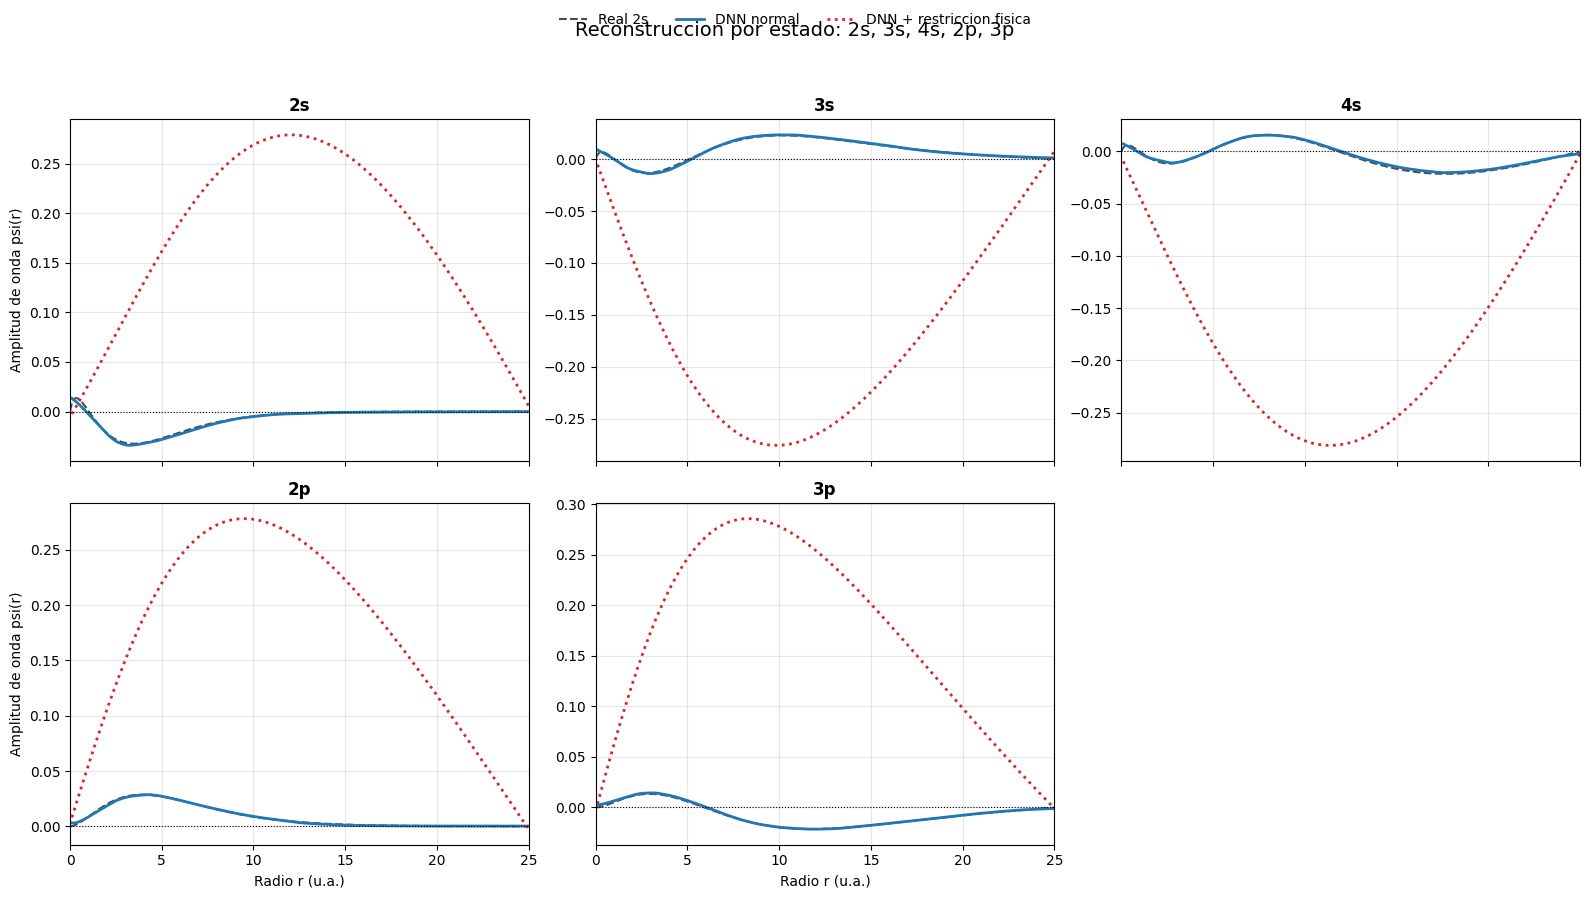

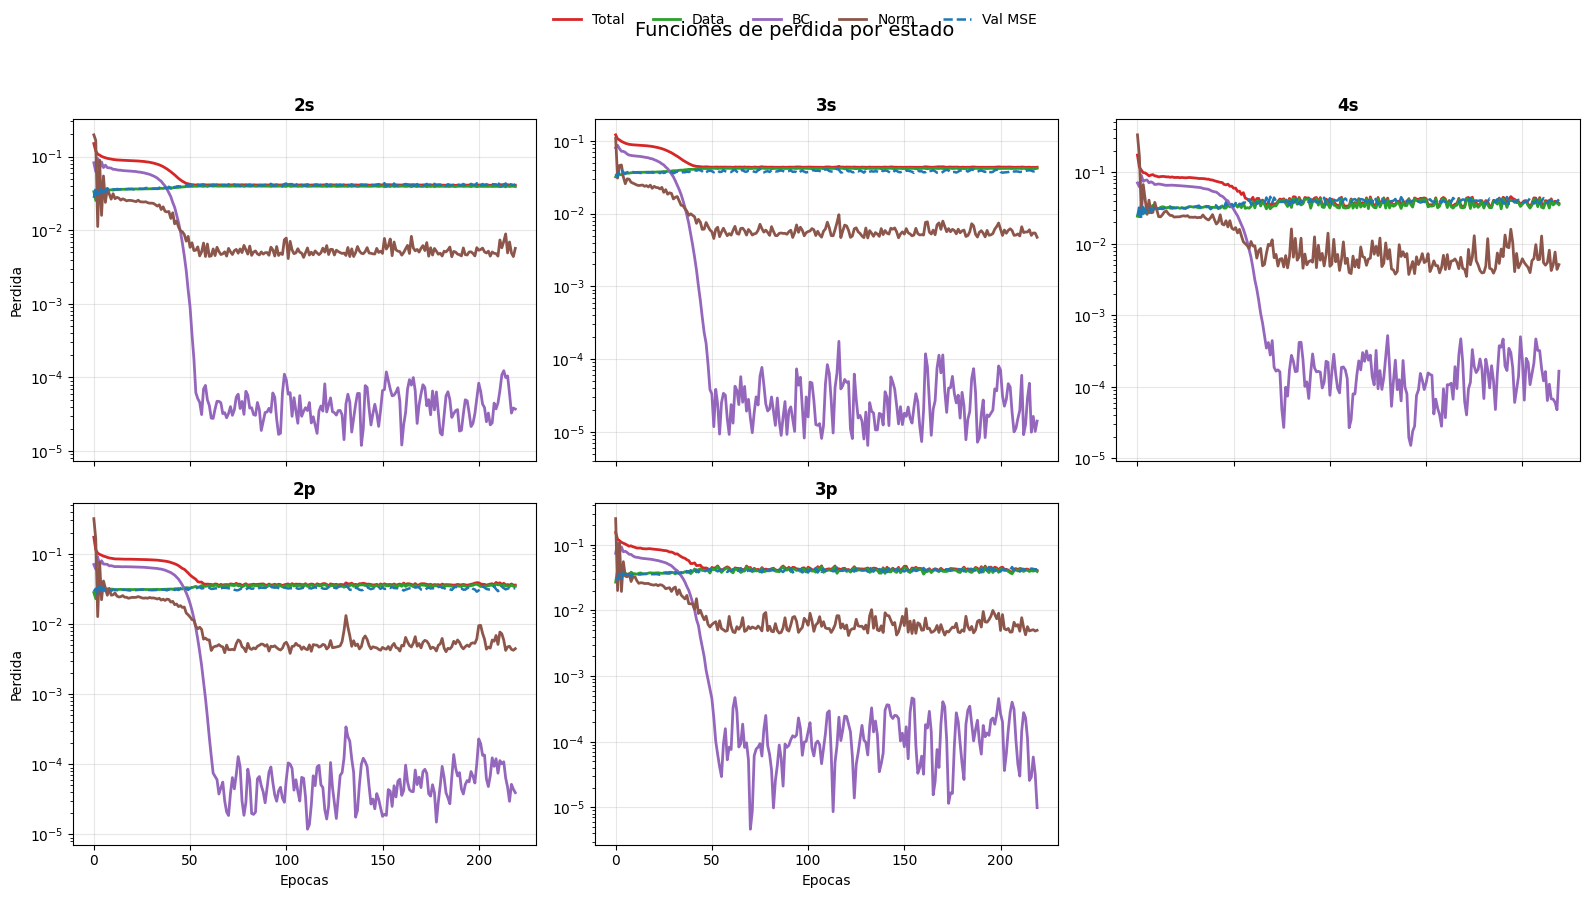

Guardado: resumen_estados_pinn_dnn.csv


In [10]:
# ==========================================================
# 7. EVALUACION MULTIESTADO + GRAFICAS (5 ESTADOS)
# ==========================================================
loss_dnn_global, mae_dnn_global = best_model.evaluate(X_test, y_test, verbose=0)

rows_metrics = []
plot_data = {}

for st in state_order:
    if st not in physics_results:
        continue

    sid = state_id_map[st]
    mask_test_target = (n_test == sid)
    nte = int(np.sum(mask_test_target))
    if nte == 0:
        print(f"[WARN] {st}: sin datos de test. Se omite en metricas/figuras.")
        continue

    r_test_target = X_test_inv[mask_test_target, 0:1].astype(np.float32)
    y_test_target = y_test[mask_test_target].astype(np.float32)

    # DNN normal para el estado
    X_test_target_scaled = scaler.transform(
        np.column_stack((r_test_target.flatten(), np.full(len(r_test_target), sid)))
    )
    t0 = time.perf_counter()
    y_pred_dnn_target = best_model.predict(X_test_target_scaled, verbose=0).flatten()
    dnn_infer_ms = (time.perf_counter() - t0) * 1000.0

    # Modelo fisico para el estado
    x_test_target_phys = ((r_test_target - float(r_min.numpy())) / float(L_domain.numpy())).astype(np.float32)
    t0 = time.perf_counter()
    y_pred_phys_target = physics_results[st]["model"].predict(x_test_target_phys, verbose=0).flatten()
    phys_infer_ms = (time.perf_counter() - t0) * 1000.0

    mse_dnn_target = float(np.mean((y_test_target - y_pred_dnn_target) ** 2))
    mse_phys_target = float(np.mean((y_test_target - y_pred_phys_target) ** 2))

    mae_dnn_target = float(np.mean(np.abs(y_test_target - y_pred_dnn_target)))
    mae_phys_target = float(np.mean(np.abs(y_test_target - y_pred_phys_target)))

    # Curvas para graficar reconstruccion
    r_plot = np.linspace(0.1, 25.0, 500)
    X_plot_dnn = scaler.transform(np.column_stack((r_plot, np.full_like(r_plot, sid))) )
    psi_pred_dnn = best_model.predict(X_plot_dnn, verbose=0).flatten()

    x_plot_phys = ((r_plot.reshape(-1, 1) - float(r_min.numpy())) / float(L_domain.numpy())).astype(np.float32)
    psi_pred_phys = physics_results[st]["model"].predict(x_plot_phys, verbose=0).flatten()

    r_real = np.array([r_data[i] for i in range(len(r_data)) if n_data[i] == sid], dtype=float)
    psi_real = np.array([psi_data[i] for i in range(len(psi_data)) if n_data[i] == sid], dtype=float)
    order_idx = np.argsort(r_real) if len(r_real) > 0 else np.array([], dtype=int)

    plot_data[st] = {
        "r_plot": r_plot,
        "psi_pred_dnn": psi_pred_dnn,
        "psi_pred_phys": psi_pred_phys,
        "r_real": r_real[order_idx] if len(order_idx) > 0 else r_real,
        "psi_real": psi_real[order_idx] if len(order_idx) > 0 else psi_real,
        "history": physics_results[st]["history"],
    }

    rows_metrics.append({
        "estado": st,
        "state_id": sid,
        "n_train": physics_results[st]["n_train"],
        "n_val": physics_results[st]["n_val"],
        "n_test": nte,
        "mse_dnn": mse_dnn_target,
        "mse_fisica": mse_phys_target,
        "mae_dnn": mae_dnn_target,
        "mae_fisica": mae_phys_target,
        "tiempo_train_fisica_s": physics_results[st]["time_train_s"],
        "tiempo_infer_dnn_ms": dnn_infer_ms,
        "tiempo_infer_fisica_ms": phys_infer_ms,
    })

metrics_df = pd.DataFrame(rows_metrics)
metrics_df = metrics_df.sort_values(by="state_id")
display(metrics_df)

print(f"\nDNN global (todos los estados) -> Test MAE: {mae_dnn_global:.6f} | Test MSE: {loss_dnn_global:.6f}")
if len(metrics_df) > 0:
    print(f"Tiempo entrenamiento DNN global: {dnn_train_time_s:.2f} s")
    print(f"Tiempo total entrenamiento fisica (5 estados): {metrics_df['tiempo_train_fisica_s'].sum():.2f} s")

# ----------------------------------------------------------
# Figura 1: reconstruccion de funciones de onda (5 graficas)
# ----------------------------------------------------------
fig1, axes1 = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
axes1 = axes1.ravel()

for i, st in enumerate(state_order):
    ax = axes1[i]
    if st not in plot_data:
        ax.set_title(f"{st} (sin datos)", fontsize=11)
        ax.axis("off")
        continue

    pdict = plot_data[st]
    ax.plot(pdict["r_real"], pdict["psi_real"], 'k--', alpha=0.7, label=f"Real {st}")
    ax.plot(pdict["r_plot"], pdict["psi_pred_dnn"], color='tab:blue', linewidth=2, label='DNN normal')
    ax.plot(pdict["r_plot"], pdict["psi_pred_phys"], color='tab:red', linewidth=2, linestyle=':', label='DNN + restriccion fisica')
    ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
    ax.set_title(st, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 25)
    if i >= 3:
        ax.set_xlabel("Radio r (u.a.)")
    if i % 3 == 0:
        ax.set_ylabel("Amplitud de onda psi(r)")

handles, labels = axes1[0].get_legend_handles_labels()
if len(handles) > 0:
    fig1.legend(handles, labels, loc='upper center', ncol=3, frameon=False)
axes1[-1].axis("off")
fig1.suptitle("Reconstruccion por estado: 2s, 3s, 4s, 2p, 3p", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ----------------------------------------------------------
# Figura 2: funciones de perdida por estado (5 graficas)
# ----------------------------------------------------------
fig2, axes2 = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
axes2 = axes2.ravel()

for i, st in enumerate(state_order):
    ax = axes2[i]
    if st not in plot_data:
        ax.set_title(f"{st} (sin datos)", fontsize=11)
        ax.axis("off")
        continue

    h = plot_data[st]["history"]
    ax.plot(h["total_loss"], linewidth=2, label='Total', color='tab:red')
    ax.plot(h["data_loss"], linewidth=2, label='Data', color='tab:green')
    ax.plot(h["bc_loss"], linewidth=2, label='BC', color='tab:purple')
    ax.plot(h["norm_loss"], linewidth=2, label='Norm', color='tab:brown')
    if np.any(~np.isnan(h["val_mse"])):
        ax.plot(h["val_mse"], linewidth=1.8, label='Val MSE', color='tab:blue', linestyle='--')

    ax.set_yscale('log')
    ax.set_title(st, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    if i >= 3:
        ax.set_xlabel("Epocas")
    if i % 3 == 0:
        ax.set_ylabel("Perdida")

handles2, labels2 = axes2[0].get_legend_handles_labels()
if len(handles2) > 0:
    fig2.legend(handles2, labels2, loc='upper center', ncol=5, frameon=False)
axes2[-1].axis("off")
fig2.suptitle("Funciones de perdida por estado", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

metrics_df.to_csv("resumen_estados_pinn_dnn.csv", index=False)
print("Guardado: resumen_estados_pinn_dnn.csv")

## Red, Penalizacion y Lambdas

> Resumen tecnico del modelo en este notebook (DNN global + red fisica por estado).

### 1) DNN global (TensorFlow/Keras)
- Entrada: $(r,\mathrm{state\_id})$
- Salida: $\hat{\psi}(r)$
- Arquitectura: MLP densa con numero de capas variable, activaciones `relu/tanh/swish`, regularizacion $L_2$ y `Dropout`.
- Loss global: MSE

$$
\mathcal{L}_{\mathrm{global}} = \frac{1}{N}\sum_{i=1}^{N}\left(\psi_i - \hat{\psi}_i\right)^2
$$

### 2) Red fisica por estado
- Entrada: $r$ normalizado
- Salida: $\hat{\psi}(r)$
- Capas:
  - Dense(64, tanh)
  - Dense(64, tanh)
  - Dense(64, tanh)
  - Dense(1)

### 3) Penalizacion fisica
La perdida total por estado es:

$$
\mathcal{L}_{\mathrm{fis}} =
\lambda_{\mathrm{data}}\,\mathcal{L}_{\mathrm{data}} +
\lambda_{\mathrm{bc}}\,\mathcal{L}_{\mathrm{bc}} +
\lambda_{\mathrm{norm}}\,\mathcal{L}_{\mathrm{norm}}
$$

con:

$$
\mathcal{L}_{\mathrm{data}} = \frac{1}{N}\sum_{i=1}^{N}\left(\psi_i - \hat{\psi}_i\right)^2
$$

$$
\mathcal{L}_{\mathrm{bc}} = \left|\hat{\psi}(r_{\min})\right|^2 + \left|\hat{\psi}(r_{\max})\right|^2
$$

$$
\mathcal{L}_{\mathrm{norm}} = \left(\int_{r_{\min}}^{r_{\max}} \left|\hat{\psi}(r)\right|^2\,dr - 1\right)^2
$$

### 4) Lambdas usadas en este notebook
$$
\lambda_{\mathrm{data}} = 1.0, \qquad
\lambda_{\mathrm{bc}} = 0.7, \qquad
\lambda_{\mathrm{norm}} = 0.3
$$

In [11]:
# ==========================================================
# 8. EXPORTAR PREDICCIONES DE LOS 5 ESTADOS OBJETIVO
# ==========================================================
print("Generando archivos de prediccion por estado...")

for st in state_order:
    if st not in physics_results:
        print(f"- {st}: omitido (sin modelo fisico entrenado)")
        continue

    sid = state_id_map[st]
    r_step = np.linspace(0.01, 25.0, 1000)

    X_input_dnn = scaler.transform(np.column_stack((r_step, np.full_like(r_step, sid))) )
    psi_pred_dnn = best_model.predict(X_input_dnn, verbose=0).flatten()

    x_step_phys = ((r_step.reshape(-1, 1) - float(r_min.numpy())) / float(L_domain.numpy())).astype(np.float32)
    psi_pred_fis = physics_results[st]["model"].predict(x_step_phys, verbose=0).flatten()

    archivo_dnn = f"LITIO_{st}_PRED_DNN.DAT"
    archivo_fis = f"LITIO_{st}_PRED_FISICA.DAT"

    with open(archivo_dnn, "w") as f_dnn:
        f_dnn.write(f"# Prediccion DNN normal para {st} (ID={sid})\n")
        f_dnn.write("# Columna 1: Radio r (u.a.) | Columna 2: Amplitud psi(r)\n\n")
        for i in range(len(r_step)):
            f_dnn.write(f"{r_step[i]:.10f}  {psi_pred_dnn[i]:.10f}\n")

    with open(archivo_fis, "w") as f_fis:
        f_fis.write(f"# Prediccion DNN con restriccion fisica para {st} (ID={sid})\n")
        f_fis.write("# Columna 1: Radio r (u.a.) | Columna 2: Amplitud psi(r)\n\n")
        for i in range(len(r_step)):
            f_fis.write(f"{r_step[i]:.10f}  {psi_pred_fis[i]:.10f}\n")

    print(f"- {st}: {archivo_dnn}, {archivo_fis}")

print("Listo: exportacion completada para los estados disponibles.")

Generando archivos de prediccion por estado...
- 2s: LITIO_2s_PRED_DNN.DAT, LITIO_2s_PRED_FISICA.DAT
- 3s: LITIO_3s_PRED_DNN.DAT, LITIO_3s_PRED_FISICA.DAT
- 4s: LITIO_4s_PRED_DNN.DAT, LITIO_4s_PRED_FISICA.DAT
- 2p: LITIO_2p_PRED_DNN.DAT, LITIO_2p_PRED_FISICA.DAT
- 3p: LITIO_3p_PRED_DNN.DAT, LITIO_3p_PRED_FISICA.DAT
Listo: exportacion completada para los estados disponibles.
